# Imports

In [1]:
from ModifiedNEAT import Population, Config
from ModifiedNEAT.nn import Sequential, Linear, NeatModule
from ModifiedNEAT.util.datetime import eta, clock
from ModifiedNEAT.optim.scheduler import CosineAnnealing
from ModifiedNEAT import nn as mnn

from torch import Tensor
from numpy import ndarray as CPUArray

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import warnings
import numpy as np
from numba.core.errors import NumbaPerformanceWarning

In [2]:
# Suppress NumbaPerformanceWarning
warnings.filterwarnings("ignore", category=NumbaPerformanceWarning)

In [3]:
torch.set_printoptions(threshold=10)

In [4]:
device = 'cuda'
dtype  = torch.float32

In [5]:
genome_num = 500

# Creating Data

In [6]:
def create(genomes_num: int):
    inp = torch.tensor([
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1],
    ])
    out = torch.tensor([
        [0],
        [1],
        [1],
        [0],
    ])
    return inp.to(device, dtype).unsqueeze(0).expand(genomes_num, *inp.shape), \
           out.to(device, dtype).unsqueeze(0).expand(genomes_num, *out.shape)

In [7]:
train_inp, train_out = create(genome_num)

In [8]:
train_inp.shape, train_out.shape

(torch.Size([500, 4, 2]), torch.Size([500, 4, 1]))

In [9]:
train_inp

tensor([[[0., 0.],
         [0., 1.],
         [1., 0.],
         [1., 1.]],

        [[0., 0.],
         [0., 1.],
         [1., 0.],
         [1., 1.]],

        [[0., 0.],
         [0., 1.],
         [1., 0.],
         [1., 1.]],

        ...,

        [[0., 0.],
         [0., 1.],
         [1., 0.],
         [1., 1.]],

        [[0., 0.],
         [0., 1.],
         [1., 0.],
         [1., 1.]],

        [[0., 0.],
         [0., 1.],
         [1., 0.],
         [1., 1.]]], device='cuda:0')

In [10]:
train_out

tensor([[[0.],
         [1.],
         [1.],
         [0.]],

        [[0.],
         [1.],
         [1.],
         [0.]],

        [[0.],
         [1.],
         [1.],
         [0.]],

        ...,

        [[0.],
         [1.],
         [1.],
         [0.]],

        [[0.],
         [1.],
         [1.],
         [0.]],

        [[0.],
         [1.],
         [1.],
         [0.]]], device='cuda:0')

# Creating Population

In [11]:
CONFIG = Config()
CONFIG.genome.init_type = 'normal'
CONFIG.genome.weight_init_mean = 0
CONFIG.genome.weight_init_std = 0.7
CONFIG.genome.weight_min_value = -np.inf # np.pi * 10
CONFIG.genome.weight_max_value = np.inf # np.pi * 10
CONFIG.genome.weight_mutate_power = 0.5
CONFIG.genome.weight_mutate_rate = 0.6
CONFIG.reproduction.min_species_size = genome_num
CONFIG.reproduction.elitism = 10
CONFIG.reproduction.survival_threshold = 0.10
CONFIG.reproduction.purge = 1
CONFIG.species.compatibility_threshold = np.inf
CONFIG.save()
CONFIG.load(2)

Created configuration 'GENERAL CONFIG' in NEAT Configuration default-neat_config.txt
Created configuration 'GENOME CONFIG' in NEAT Configuration default-neat_config.txt
Created configuration 'SPECIES CONFIG' in NEAT Configuration default-neat_config.txt
Created configuration 'STAGNATION CONFIG' in NEAT Configuration default-neat_config.txt
Created configuration 'REPRODUCTION CONFIG' in NEAT Configuration default-neat_config.txt
fitness_criterion         = max
fitness_threshold         = inf
pop_size                  = 100
reset_on_extinction       = True
seed                      = 74
Loaded configuration 'GENERAL CONFIG' in NEAT Configuration default-neat_config.txt
weight_init_mean          = 0
weight_init_std           = 0.7
weight_max_value          = inf
weight_min_value          = -inf
weight_mutate_power       = 0.5
weight_mutate_rate        = 0.6
weight_replace_rate       = 0.05
bias_init_mean            = 0.0
bias_init_std             = 1.0
bias_max_value            = inf
bias

In [12]:
def model_size(model: NeatModule):
    return np.sum([param.numel() for param in model.parameters()])

In [13]:
BATCH_SIZE  = 8
INPUT_DIMS  = 2
OUTPUT_DIMS = 1
DIM_SIZE    = 8
LAYERS      = 1
BIAS        = True

In [14]:
MODEL = Sequential(
    mnn.Transpose(),
    mnn.Conv1d(INPUT_DIMS, DIM_SIZE, 1, padding=-1, bias=BIAS, device=device, dtype=dtype),
    nn.SiLU(),
    mnn.Conv1d(DIM_SIZE, OUTPUT_DIMS, 1, padding=-1, bias=BIAS, device=device, dtype=dtype),
    mnn.Transpose(),
    nn.Sigmoid(),
)
# linear = Linear(input_dims, output_dims, bias, device, dtype)
POPULATION = Population(genome_num, MODEL, CONFIG, init_reporter=True)
MODEL, model_size(MODEL)

Initialized genomes in  in 0.4s
Ran distance kernel in 0.17 s
Created distances cache in 1.88 s
Collected species representatives in 2.67 s
Filled species in 1.25 s
Updated species mapping in 0.84 s
Completed speciating in 6.64 s
Mean genetic distance 1.569, standard deviation 0.343, with 1 species


(Sequential[NeatModule](
   (0): Transpose(dim0=-1, dim1=-2)
   (1): Conv1d[NeatModule](channels_in=2, channels_out=8, kernel_size=(1,), stride=1, padding=(0,), dilation=1, groups=1, bias=True, padding_mode=constant)
   (2): SiLU()
   (3): Conv1d[NeatModule](channels_in=8, channels_out=1, kernel_size=(1,), stride=1, padding=(0,), dilation=1, groups=1, bias=True, padding_mode=constant)
   (4): Transpose(dim0=-1, dim1=-2)
   (5): Sigmoid()
 ),
 16500)

In [15]:
MODEL.modules

<bound method Module.modules of Sequential[NeatModule](
  (0): Transpose(dim0=-1, dim1=-2)
  (1): Conv1d[NeatModule](channels_in=2, channels_out=8, kernel_size=(1,), stride=1, padding=(0,), dilation=1, groups=1, bias=True, padding_mode=constant)
  (2): SiLU()
  (3): Conv1d[NeatModule](channels_in=8, channels_out=1, kernel_size=(1,), stride=1, padding=(0,), dilation=1, groups=1, bias=True, padding_mode=constant)
  (4): Transpose(dim0=-1, dim1=-2)
  (5): Sigmoid()
)>

In [16]:
# arr = np.round(linear.modules_list[0].weights.data.cpu().numpy(), 4)
# arr[..., 0]

In [17]:
lin_unit = MODEL.modules_list[1]
torch.sum(lin_unit.kernels.data > 0), torch.sum(lin_unit.kernels.data < 0), torch.sum(lin_unit.kernels.data == 0)

(tensor(4050, device='cuda:0'),
 tensor(3950, device='cuda:0'),
 tensor(0, device='cuda:0'))

In [18]:
g_idx = np.random.randint(MODEL.genome_num)
o = MODEL(train_inp) # , verbose=4)
# o, w, b = o[g_idx].cpu().numpy(), w[g_idx].cpu().numpy(), b # [g_idx].cpu().numpy()
g_idx

247

In [19]:
train_inp[g_idx].cpu().numpy()

array([[0., 0.],
       [0., 1.],
       [1., 0.],
       [1., 1.]], dtype=float32)

In [20]:
o[g_idx].cpu().numpy()

array([[0.61283654],
       [0.70625985],
       [0.7548464 ],
       [0.7703903 ]], dtype=float32)

In [21]:
# w

In [22]:
# b

In [23]:
outputs = MODEL(train_inp)
outputs.shape

torch.Size([500, 4, 1])

In [24]:
outputs[0].cpu().numpy()

array([[0.1645979 ],
       [0.04741   ],
       [0.12057551],
       [0.06813428]], dtype=float32)

In [25]:
for i, out in enumerate(train_out[0]):
    print(f"Record {i+1}: {out.shape}")
    print(torch.round(out, decimals=4))
    plt.show()

Record 1: torch.Size([1])
tensor([0.], device='cuda:0')
Record 2: torch.Size([1])
tensor([1.], device='cuda:0')
Record 3: torch.Size([1])
tensor([1.], device='cuda:0')
Record 4: torch.Size([1])
tensor([0.], device='cuda:0')


In [26]:
for i, out in enumerate(outputs[0]):
    print(f"Record {i+1}: {out.shape}")
    print(torch.round(out, decimals=4))
    plt.show()

Record 1: torch.Size([1])
tensor([0.1646], device='cuda:0')
Record 2: torch.Size([1])
tensor([0.0474], device='cuda:0')
Record 3: torch.Size([1])
tensor([0.1206], device='cuda:0')
Record 4: torch.Size([1])
tensor([0.0681], device='cuda:0')


In [27]:
# def plot_attention(attention: list[Tensor], genome_index: int, layer_index: int, records: int, randomize=False, size=(1440, 1080), inverse=False, cmap='bone_r'):
#     attention: Tensor = attention[layer_index]
#     g, b, heads, q, k = attention.shape
#     fig, axes = plt.subplots(records, heads, figsize=(size[0]*0.01, size[1]*0.01))
#     if isinstance(axes, CPUArray):
#         axes = axes.flatten()
#     else:
#         axes = [axes]
#     if inverse:
#         axes = axes[::-1]
#     x = 0
#     if not randomize:
#         indices = torch.arange(records)
#     else:
#         indices = torch.randperm(attention.size(1))[:records]
#     for i, record in enumerate(torch.index_select(attention[genome_index], 0, indices.to(device))):
#         for j, att_head in enumerate(record):
#             if q == 1:
#                 att_head = att_head.expand(k, k)
#             axes[x].imshow(att_head.float().cpu(), cmap=cmap)
#             x += 1
#     plt.show()
#     return att_head

# Training

In [28]:
def accuracy(prediction: Tensor, target: Tensor, error=0.01):
    total: Tensor = ((prediction >= target*(1-error)) & (prediction <= target*(1+error))) == True
    dims = tuple(range(1, train_out.ndim))
    size = np.prod(total.shape[1:])
    acc = (total.float().count_nonzero(dims) / size)
    print(acc.shape)
    acc = acc.max().cpu().item()
    return np.round(acc, 4) * 100

In [29]:
accuracy(MODEL(train_inp), train_out)

torch.Size([500])


25.0

In [30]:
scheduler = CosineAnnealing(CONFIG, 10, 0.1, 'weight_mutate_power', True, True)

In [31]:
def evaluation(population: Population, **options):
    global train_inp, train_out
    if MODEL.genome_num != train_inp.shape[0]:
        train_inp, train_out = create(MODEL.genome_num)

    losses_plot: list[float] = options['losses']
    genomes_plot: list[float] = options['genomes']

    pred_out = MODEL(train_inp)

    dims = tuple(range(1, train_out.ndim))
    losses = torch.mean((train_out-pred_out) ** 2, dims)
    # if len(losses_plot) <= 3:
    #     print(f"\nLosses: {losses.shape} prediction: {pred_out.shape} target: {train_out.shape}")
    losses_plot.append(losses.min().cpu().item())
    scores = (- losses).cpu().numpy()

    for score, gid in zip(scores, population.get_mapping(consolidated=True)):
        population.genomes[gid].fitness = score

    ranking = list(sorted({k: g.fitness for k, g in population.genomes.items()}.items(), key=lambda item: item[1]))
    genomes_plot.append(ranking[0][0])

In [32]:
def train(epochs: int, show=True, checkpoints=5):
    torch.cuda.empty_cache()
    losses: list[float] = []
    genomes: list[int] = []
    fitness: list[float] = []

    ts = clock.perf_counter()
    scheduler.reset()
    try:
        for epoch in range(epochs):
            POPULATION.run(evaluation, 1,
                           losses=losses, genomes=genomes,
                           verbose=False if epoch == 0 else False)
            scheduler.step()
            # if epoch < 3:
            #     print(f"\nBest Genome: {POPULATION.best_genome}")
            #     print(f"Model mapping: {list(MODEL.mapping.keys())[:10]}")
            #     print(f"Genome mapping: {list(POPULATION.get_mapping(consolidated=True))[:10]}\n")
            fitness.append(POPULATION.best_genome.fitness)

            eta(ts, epoch+1, epochs, f"NEAT training")
    except KeyboardInterrupt as e:
        print(e)
    print(f"finished NEAT training in {clock.perf_counter() - ts:.1f}s")

    # attention.causal_mask = True
    if show:
        plt.plot(np.log10(losses))
        plt.title(f"Loss")
        plt.show()
        plt.plot(genomes)
        plt.title(f"Genome")
        plt.show()
        plt.plot(fitness)
        plt.title(f"Fitness")
        plt.show()

    torch.cuda.empty_cache()
    return losses

NEAT training: progress=100% eta=0secfinished NEAT training in 23.4s


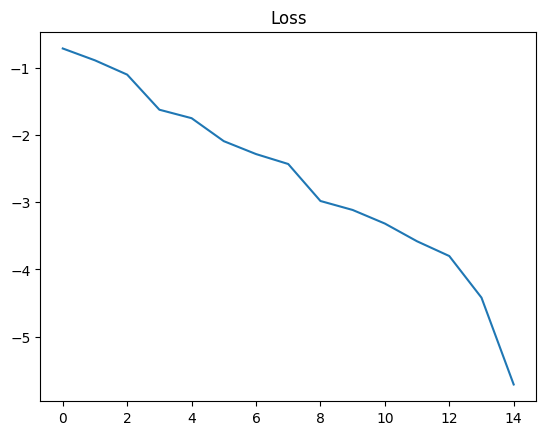

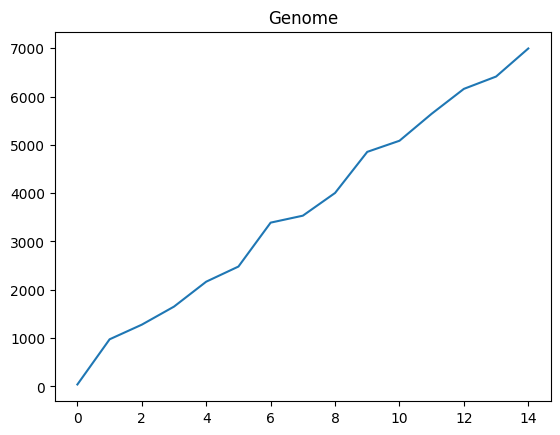

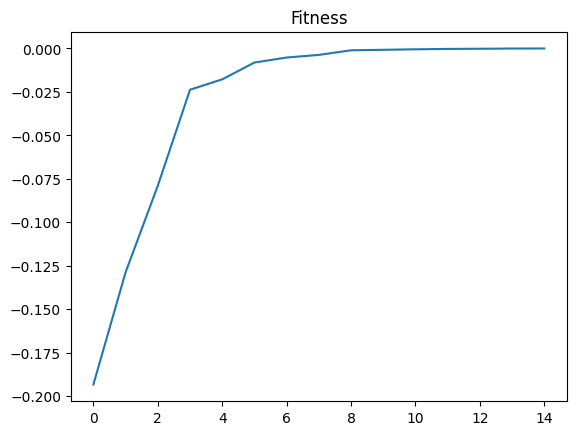

In [33]:
neat_losses = train(15)

 # Evaluation

In [34]:
CONFIG.genome.weight_mutate_power

0.12946307421270078

In [35]:
params = MODEL.neat_parameters()
len(params)

4

In [36]:
param_index = np.random.randint(len(params))
param = params[param_index]
param_index

3

In [37]:
MODEL.neat_modules()[0].mapping

{7097: 0,
 7096: 1,
 7189: 2,
 6968: 3,
 6891: 4,
 7149: 5,
 7260: 6,
 7078: 7,
 7182: 8,
 6974: 9,
 7360: 10,
 7361: 11,
 7362: 12,
 7363: 13,
 7364: 14,
 7365: 15,
 7366: 16,
 7367: 17,
 7368: 18,
 7369: 19,
 7370: 20,
 7371: 21,
 7372: 22,
 7373: 23,
 7374: 24,
 7375: 25,
 7376: 26,
 7377: 27,
 7378: 28,
 7379: 29,
 7380: 30,
 7381: 31,
 7382: 32,
 7383: 33,
 7384: 34,
 7385: 35,
 7386: 36,
 7387: 37,
 7388: 38,
 7389: 39,
 7390: 40,
 7391: 41,
 7392: 42,
 7393: 43,
 7394: 44,
 7395: 45,
 7396: 46,
 7397: 47,
 7398: 48,
 7399: 49,
 7400: 50,
 7401: 51,
 7402: 52,
 7403: 53,
 7404: 54,
 7405: 55,
 7406: 56,
 7407: 57,
 7408: 58,
 7409: 59,
 7410: 60,
 7411: 61,
 7412: 62,
 7413: 63,
 7414: 64,
 7415: 65,
 7416: 66,
 7417: 67,
 7418: 68,
 7419: 69,
 7420: 70,
 7421: 71,
 7422: 72,
 7423: 73,
 7424: 74,
 7425: 75,
 7426: 76,
 7427: 77,
 7428: 78,
 7429: 79,
 7430: 80,
 7431: 81,
 7432: 82,
 7433: 83,
 7434: 84,
 7435: 85,
 7436: 86,
 7437: 87,
 7438: 88,
 7439: 89,
 7440: 90,
 7441: 91

In [38]:
param.data[param_index]

tensor([1.8865], device='cuda:0')

In [39]:
MODEL.mapping

{7097: 0,
 7096: 1,
 7189: 2,
 6968: 3,
 6891: 4,
 7149: 5,
 7260: 6,
 7078: 7,
 7182: 8,
 6974: 9,
 7360: 10,
 7361: 11,
 7362: 12,
 7363: 13,
 7364: 14,
 7365: 15,
 7366: 16,
 7367: 17,
 7368: 18,
 7369: 19,
 7370: 20,
 7371: 21,
 7372: 22,
 7373: 23,
 7374: 24,
 7375: 25,
 7376: 26,
 7377: 27,
 7378: 28,
 7379: 29,
 7380: 30,
 7381: 31,
 7382: 32,
 7383: 33,
 7384: 34,
 7385: 35,
 7386: 36,
 7387: 37,
 7388: 38,
 7389: 39,
 7390: 40,
 7391: 41,
 7392: 42,
 7393: 43,
 7394: 44,
 7395: 45,
 7396: 46,
 7397: 47,
 7398: 48,
 7399: 49,
 7400: 50,
 7401: 51,
 7402: 52,
 7403: 53,
 7404: 54,
 7405: 55,
 7406: 56,
 7407: 57,
 7408: 58,
 7409: 59,
 7410: 60,
 7411: 61,
 7412: 62,
 7413: 63,
 7414: 64,
 7415: 65,
 7416: 66,
 7417: 67,
 7418: 68,
 7419: 69,
 7420: 70,
 7421: 71,
 7422: 72,
 7423: 73,
 7424: 74,
 7425: 75,
 7426: 76,
 7427: 77,
 7428: 78,
 7429: 79,
 7430: 80,
 7431: 81,
 7432: 82,
 7433: 83,
 7434: 84,
 7435: 85,
 7436: 86,
 7437: 87,
 7438: 88,
 7439: 89,
 7440: 90,
 7441: 91

In [40]:
len(MODEL.mapping), len(POPULATION.genomes), MODEL.genome_num

(500, 500, 500)

In [41]:
best_key = POPULATION.best_genome.key if POPULATION.best_genome and POPULATION.best_genome.key in POPULATION.genomes is not None else None
best_key

7097

In [42]:
train_inp.shape

torch.Size([500, 4, 2])

In [43]:
# accuracy(linear(eval_inp, keys=best_key), eval_out), \
accuracy(MODEL(train_inp[0].unsqueeze(0), keys=best_key), train_out)

torch.Size([500])


50.0

In [44]:
train_inp.shape

torch.Size([500, 4, 2])

In [45]:
outputs = MODEL(train_inp[0].unsqueeze(0), keys=best_key)
if best_key is not None:
    outputs = outputs[MODEL.mapping[best_key]].unsqueeze(0)

In [46]:
outputs.shape

torch.Size([1, 4, 1])

In [47]:
for i, out in enumerate(train_out[0]):
    print(f"Record {i+1}: {out.shape}")
    print(torch.round(out, decimals=4))
    plt.show()

Record 1: torch.Size([1])
tensor([0.], device='cuda:0')
Record 2: torch.Size([1])
tensor([1.], device='cuda:0')
Record 3: torch.Size([1])
tensor([1.], device='cuda:0')
Record 4: torch.Size([1])
tensor([0.], device='cuda:0')


In [48]:
for i, out in enumerate(outputs[0]):
    print(f"Record {i+1}: {out.shape}")
    print(torch.round(out, decimals=4))
    plt.show()

Record 1: torch.Size([1])
tensor([0.0010], device='cuda:0')
Record 2: torch.Size([1])
tensor([0.9988], device='cuda:0')
Record 3: torch.Size([1])
tensor([0.9985], device='cuda:0')
Record 4: torch.Size([1])
tensor([0.0017], device='cuda:0')


# Pytorch Implementation

In [49]:
import torch.optim as optim
import torch.nn.functional as F

In [50]:
linear2 = nn.Sequential(
    mnn.Transpose(),
    nn.Conv1d(INPUT_DIMS, DIM_SIZE, 1, padding=0, bias=BIAS, device=device, dtype=dtype),
    nn.SiLU(),
    nn.Conv1d(DIM_SIZE, OUTPUT_DIMS, 1, padding=0, bias=BIAS, device=device, dtype=dtype),
    mnn.Transpose(),
    nn.Sigmoid(),
)
linear2

Sequential(
  (0): Transpose(dim0=-1, dim1=-2)
  (1): Conv1d(2, 8, kernel_size=(1,), stride=(1,))
  (2): SiLU()
  (3): Conv1d(8, 1, kernel_size=(1,), stride=(1,))
  (4): Transpose(dim0=-1, dim1=-2)
  (5): Sigmoid()
)

In [51]:
optimizer = optim.RAdam(linear2.parameters(), 1e-2)

In [52]:
def train2(epochs: int, show=True, checkpoints=5):
    torch.cuda.empty_cache()
    linear2.requires_grad_(True)
    # attention.causal_mask = False

    losses = []
    ts, ud, ut = clock.perf_counter(), 0, epochs

    dims = tuple(range(1, train_out.ndim))
    best_loss = F.mse_loss(linear2(train_inp), train_out)
    best_epoch = -1
    save_state = linear2.state_dict()
    for epoch in range(epochs):
        try:
            optimizer.zero_grad()
            test_actv = linear2(train_inp)
            loss = F.mse_loss(test_actv, train_out)
            loss.backward()
            optimizer.step()

            losses.append(loss.cpu().item())

            if epoch % checkpoints == 0 and loss < best_loss:
                best_loss = loss
                save_state = linear2.state_dict()
                best_epoch = epoch

            ud += 1
            eta(ts, ud, ut, f"training | loss={loss.cpu().item(): .4e} | "
                            f"best={best_loss.cpu().item(): .4e} | "
                            f"epoch={best_epoch}")
        except KeyboardInterrupt:
            break
    print(f"\nFinished training in {clock.perf_counter()-ts:.2f}s")

    linear2.load_state_dict(save_state)

    # attention.causal_mask = True
    if show:
        plt.plot(np.log10(losses))
        plt.title(f"Loss")

    linear2.requires_grad_(False)
    torch.cuda.empty_cache()
    return losses

training | loss= 1.3286e-10 | best= 1.3286e-10 | epoch=22999: progress=100% eta=0sec
Finished training in 39.63s


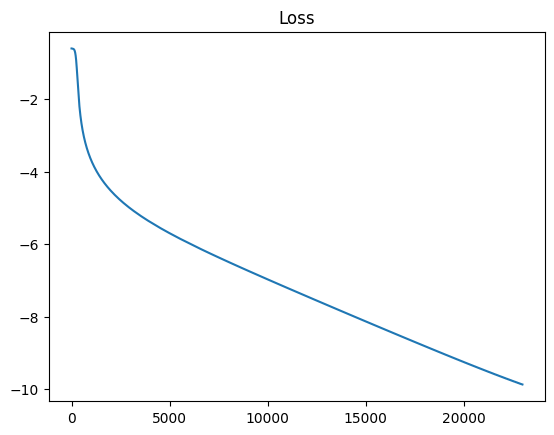

In [53]:
train_losses = train2(25000, checkpoints=1)

In [54]:
min(neat_losses), min(train_losses)

(4.7821034968364984e-05, 1.328591681115654e-10)

In [55]:
# linear2.modules_list[0].weights[best_key]

In [56]:
# linear2.modules_list[0].biases[best_key]

In [57]:
outputs = linear2(train_inp) #, keys=best_key)
# if best_key is not None:
#     outputs = outputs[linear2.mapping[best_key]].unsqueeze(0)
for i, out in enumerate(outputs[0]):
    print(f"Record {i+1}: {out.shape}")
    print(torch.round(out, decimals=4))
    plt.show()

Record 1: torch.Size([1])
tensor([0.], device='cuda:0')
Record 2: torch.Size([1])
tensor([1.], device='cuda:0')
Record 3: torch.Size([1])
tensor([1.], device='cuda:0')
Record 4: torch.Size([1])
tensor([0.], device='cuda:0')


In [58]:
# plot_attention(att, 0, 0, 3, True, size=(1080, 720))

tensor([[ 0,  1,  2,  ...,  7,  8,  9],
        [10, 11, 12,  ..., 17, 18, 19],
        [20, 21, 22,  ..., 27, 28, 29],
        ...,
        [70, 71, 72,  ..., 77, 78, 79],
        [80, 81, 82,  ..., 87, 88, 89],
        [90, 91, 92,  ..., 97, 98, 99]])

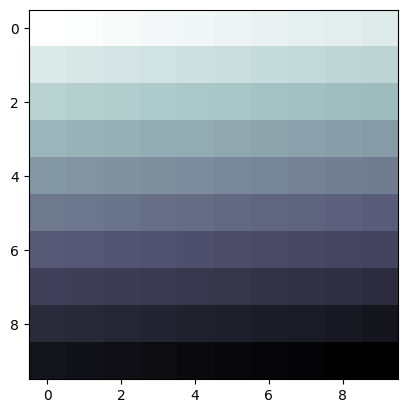

In [59]:
plt.imshow(torch.arange(10*10).view(10, 10), cmap='bone_r')
torch.arange(10*10).view(10, 10)